# Create RDS files for Seurat Label Transfer
* Xenium AnnData -> RDS
* Reference AnnData -> RDS

In [1]:
library(Seurat)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [2]:
base_dir <- "/home/workspace/projects/drg/data/rds"

adata_dir   <- file.path(base_dir, "xenium")
refdata_dir <- file.path(base_dir, "refdata")

In [3]:
load_seurat_from_csv <- function(dataset_dir, project_name) {

  message("Loading dataset from: ", dataset_dir)

  ############################################
  # Determine assay name based on dataset
  ############################################
  if (grepl("xenium", project_name, ignore.case = TRUE)) {
    assay_name <- "Xenium"
  } else {
    assay_name <- "RNA"
  }

  ############################################
  # Counts: ZIP file created by your export
  ############################################
  zip_file <- file.path(dataset_dir, "counts_matrix.zip")
  stopifnot(file.exists(zip_file))

  tmpdir <- tempfile()
  dir.create(tmpdir)

  message("Unzipping counts_matrix.zip ...")
  unzip(zip_file, exdir = tmpdir)

  mtx_file      <- file.path(tmpdir, "matrix.mtx.gz")
  barcodes_file <- file.path(tmpdir, "barcodes.tsv.gz")
  features_file <- file.path(tmpdir, "features.tsv.gz")
  cell_md_file  <- file.path(dataset_dir, "metadata", "cell-metadata.csv")

  stopifnot(file.exists(mtx_file))
  stopifnot(file.exists(barcodes_file))
  stopifnot(file.exists(features_file))

  message("Reading Matrix Market counts...")
  counts_matrix <- ReadMtx(
    mtx     = mtx_file,
    cells   = barcodes_file,
    features = features_file,
    feature.column = 1
  )

  ############################################
  # Build Seurat object
  ############################################
  seu <- CreateSeuratObject(counts = counts_matrix, project = project_name)

  # IMPORTANT FIX: rename assay for Xenium
  if (assay_name == "Xenium") {
    seu <- RenameAssays(seu, RNA = "Xenium")
  }

  ############################################
  # Load cell metadata
  ############################################
  if (file.exists(cell_md_file)) {
    message("Loading cell metadata...")
    md <- read.csv(cell_md_file)

    rownames(md) <- md[,1]
    md <- md[,-1, drop = FALSE]

    md <- md[colnames(seu), , drop = FALSE]
    seu <- AddMetaData(seu, md)
  } else {
    message("Skipping cell metadata (file not found).")
  }

############################################
# Load feature metadata
############################################
metadata_dir <- file.path(dataset_dir, "metadata")
feature_metadata_file <- file.path(metadata_dir, "feature-metadata.csv")

if (file.exists(feature_metadata_file)) {
  message("Loading feature metadata...")

  # Read feature metadata normally
  feature_metadata <- read.csv(feature_metadata_file)

  # FIRST column is the gene identifier (from your CSV export)
  rownames(feature_metadata) <- feature_metadata[,1]

  # Keep all columns, including gene_name
  # Align rows to Seurat gene order
  common_genes <- intersect(rownames(seu), rownames(feature_metadata))
  feature_metadata <- feature_metadata[common_genes, , drop = FALSE]

  # Add each column into Seurat feature-level meta.data
  for (colname in colnames(feature_metadata)) {
    seu[[colname]] <- feature_metadata[[colname]]
  }

} else {
  message("Skipping feature metadata (file not found).")
}

  ############################################
  # Dimensional reductions
  ############################################
  reduc_dir <- file.path(dataset_dir, "reductions")

  latent_file <- file.path(reduc_dir, "latent_representation.csv")
  if (file.exists(latent_file)) {
    message("Loading latent representation...")
    latent <- read.csv(latent_file, row.names = 1)

    colnames(latent) <- paste0("latent_", seq_len(ncol(latent)))

    seu[["latent"]] <- CreateDimReducObject(
      embeddings = as.matrix(latent),
      key = "latent_",
      assay = assay_name
    )
  } else {
    message("Skipping latent representation (file not found).")
  }

  umap_file <- file.path(reduc_dir, "umap.csv")
  if (file.exists(umap_file)) {
    message("Loading UMAP...")
    umap <- read.csv(umap_file, row.names = 1)

    colnames(umap) <- paste0("umap_", seq_len(ncol(umap)))

    seu[["umap"]] <- CreateDimReducObject(
      embeddings = as.matrix(umap),
      key = "UMAP_",
      assay = assay_name
    )
  } else {
    message("Skipping UMAP (file not found).")
  }

  return(seu)
}

In [4]:
adata_seurat   <- load_seurat_from_csv(adata_dir,   project_name = "adata_xenium")
refdata_seurat <- load_seurat_from_csv(refdata_dir, project_name = "refdata_seq")

Loading dataset from: /home/workspace/projects/drg/data/rds/xenium

Unzipping counts_matrix.zip ...

Reading Matrix Market counts...

Renaming default assay from RNA to Xenium

Warning message:
“Key ‘rna_’ taken, using ‘xenium_’ instead”
Loading cell metadata...

Loading feature metadata...

Loading latent representation...

Loading UMAP...

Loading dataset from: /home/workspace/projects/drg/data/rds/refdata

Unzipping counts_matrix.zip ...

Reading Matrix Market counts...

Loading cell metadata...

Loading feature metadata...

Loading latent representation...

Loading UMAP...



In [5]:
####################################################################################################
# Save both .RDS outputs
####################################################################################################

save_dir <- "/home/workspace/projects/drg/data/rds/seurat"
dir.create(save_dir, recursive = TRUE, showWarnings = FALSE)

saveRDS(adata_seurat,   file = file.path(save_dir, "adata-xenium.rds"))
saveRDS(refdata_seurat, file = file.path(save_dir, "refdata-seq.rds"))

message("Saved RDS files:")
message(" - ", file.path(save_dir, "adata-xenium.rds"))
message(" - ", file.path(save_dir, "refdata-seq.rds"))

Saved RDS files:

 - /home/workspace/projects/drg/data/rds/seurat/adata-xenium.rds

 - /home/workspace/projects/drg/data/rds/seurat/refdata-seq.rds



Successfully loaded:

  - /home/workspace/projects/drg/data/rds/seurat/adata-xenium.rds

  - /home/workspace/projects/drg/data/rds/seurat/refdata-seq.rds

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



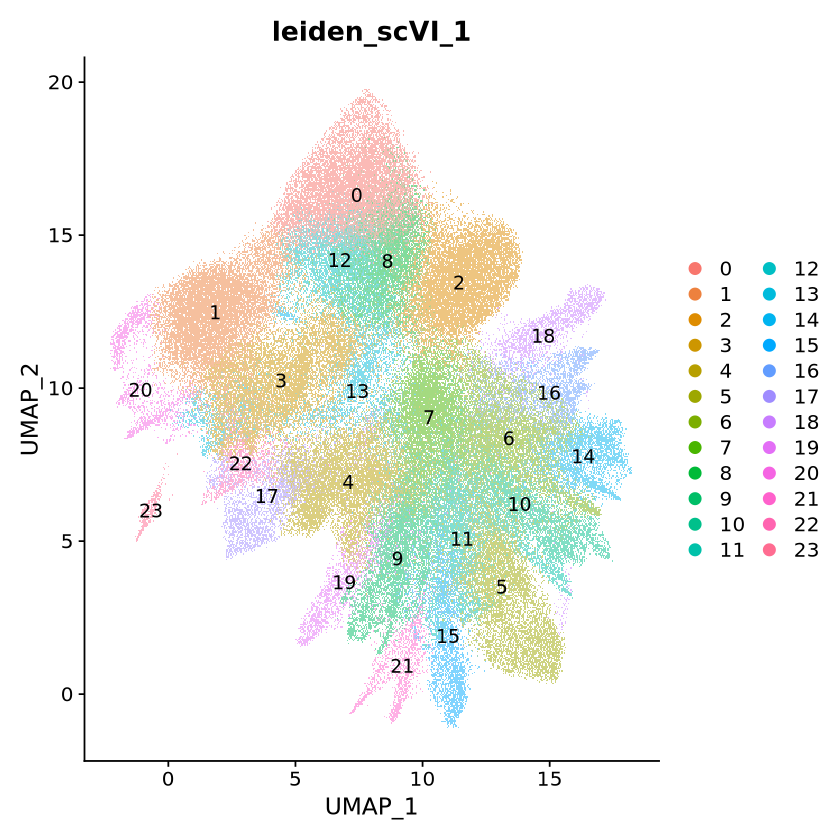

Warning message:
“The following requested variables were not found: cell_labels”


ERROR: Error in `[.data.frame`(data, , group): undefined columns selected


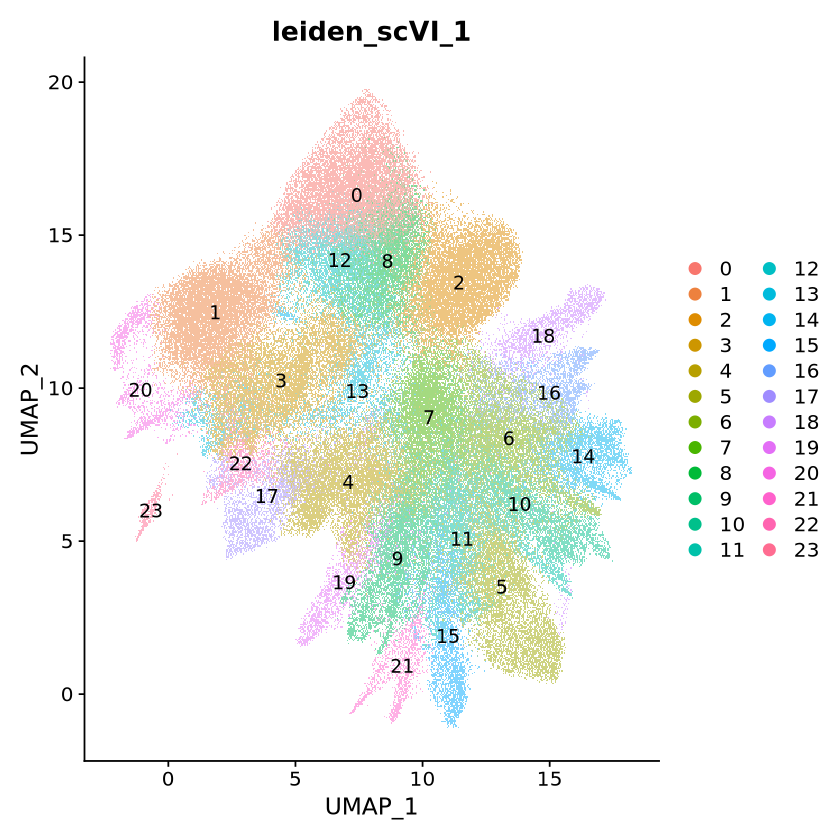

In [6]:
# test import and visualize umap
adata_rds   <- file.path(save_dir, "adata-xenium.rds")
refdata_rds <- file.path(save_dir, "refdata-seq.rds")

# Load Seurat objects
adata_seurat   <- readRDS(adata_rds)
refdata_seurat <- readRDS(refdata_rds)

message("Successfully loaded:")
message("  - ", adata_rds)
message("  - ", refdata_rds)

####################################################################################################
# UMAP VISUALIZATION (adata)
####################################################################################################

# UMAP by cell type
DimPlot(
  adata_seurat,
  reduction = "umap",
  group.by  = "leiden_scVI_1",
  label     = TRUE,
  pt.size   = 0.5
)# + ggtitle("adata: UMAP by Cell Type")


# UMAP by Leiden
DimPlot(
  adata_seurat,
  reduction = "umap",
  group.by  = "leiden_scVI_1",
  label     = TRUE,
  pt.size   = 0.5
) #+ ggtitle("adata: UMAP by Leiden")

####################################################################################################
# UMAP VISUALIZATION (refdata)
####################################################################################################

DimPlot(
  refdata_seurat,
  reduction = "umap",
  group.by  = "cell_labels",
  label     = TRUE,
  pt.size   = 0.5
)# + ggtitle("refdata: UMAP by Cell Type")

# backup/nlotes

In [8]:
"""
library(Seurat)

####################################################################################################
# Function: Load ONE dataset (adata OR refdata) from your CSV export structure
####################################################################################################

load_seurat_from_csv <- function(dataset_dir, project_name) {

  message("Loading dataset from: ", dataset_dir)

  # Define subdirectories
  data_dir      <- file.path(dataset_dir, "data")
  metadata_dir  <- file.path(dataset_dir, "metadata")
  reduc_dir     <- file.path(dataset_dir, "reductions")

  # ------------------------- Load matrices -------------------------
  counts_file <- file.path(data_dir, "counts-matrix.csv")
  stopifnot(file.exists(counts_file))

  message("Reading counts matrix...")
  counts_matrix <- read.csv(counts_file, row.names = 1)
  counts_matrix <- t(as.matrix(counts_matrix))

  # ------------------------- Create Seurat object -------------------------
  seu <- CreateSeuratObject(counts = counts_matrix, project = project_name)

  # ------------------------- Load metadata -------------------------
  cell_metadata_file    <- file.path(metadata_dir, "cell-metadata.csv")
  feature_metadata_file <- file.path(metadata_dir, "feature-metadata.csv")

  ## Cell metadata
  if (file.exists(cell_metadata_file)) {
    message("Loading cell metadata...")
    cell_metadata <- read.csv(cell_metadata_file, row.names = 1)
    seu <- AddMetaData(seu, metadata = cell_metadata)
  } else {
    message("Skipping cell metadata (file not found).")
  }

  ## Feature metadata
  if (file.exists(feature_metadata_file)) {
    message("Loading feature metadata...")
    feature_metadata <- read.csv(feature_metadata_file, row.names = 1)

    # Only keep overlapping genes
    common_genes <- intersect(rownames(seu), rownames(feature_metadata))
    feature_metadata <- feature_metadata[common_genes, , drop = FALSE]

    for (colname in colnames(feature_metadata)) {
      seu <- AddMetaData(seu, metadata = feature_metadata[[colname]], col.name = colname)
    }
  } else {
    message("Skipping feature metadata (file not found).")
  }

  # ------------------------- Load dimensional reductions -------------------------

  # PCA
  pca_file <- file.path(reduc_dir, "pca.csv")
  if (file.exists(pca_file)) {
    message("Loading PCA reduction...")
    pca_coords <- read.csv(pca_file, check.names = FALSE, row.names = 1)
    colnames(pca_coords) <- paste0("PC_", 1:ncol(pca_coords))
    seu[["pca"]] <- CreateDimReducObject(embeddings = as.matrix(pca_coords), key = "PC_")
  } else {
    message("Skipping PCA (file not found).")
  }

  # scVI latent
  latent_file <- file.path(reduc_dir, "latent_representation.csv")
  if (file.exists(latent_file)) {
    message("Loading scVI latent representation...")
    latent <- read.csv(latent_file, check.names = FALSE, row.names = 1)
    colnames(latent) <- paste0("latent_", 1:ncol(latent))
    seu[["latent"]] <- CreateDimReducObject(embeddings = as.matrix(latent), key = "latent_")
  } else {
    message("Skipping latent representation (file not found).")
  }

  # UMAP
  umap_file <- file.path(reduc_dir, "umap.csv")
  if (file.exists(umap_file)) {
    message("Loading UMAP reduction...")
    umap_coords <- read.csv(umap_file, row.names = 1)
    colnames(umap_coords) <- paste0("umap_", 1:ncol(umap_coords))
    seu[["umap"]] <- CreateDimReducObject(embeddings = as.matrix(umap_coords), key = "UMAP_")
  } else {
    message("Skipping UMAP (file not found).")
  }

  return(seu)

"""

ERROR: Error in parse(text = input): <text>:1:3: unexpected string constant
9: 
10:   message("
      ^


In [ ]:
"""# working version
load_seurat_from_csv <- function(dataset_dir, project_name) {

  message("Loading dataset from: ", dataset_dir)

  ############################################
  # Counts: ZIP file created by your export
  ############################################

  zip_file <- file.path(dataset_dir, "counts_matrix.zip")
  stopifnot(file.exists(zip_file))

  tmpdir <- tempfile()
  dir.create(tmpdir)

  message("Unzipping counts_matrix.zip ...")
  unzip(zip_file, exdir = tmpdir)

  mtx_file      <- file.path(tmpdir, "matrix.mtx.gz")
  barcodes_file <- file.path(tmpdir, "barcodes.tsv.gz")
  features_file <- file.path(tmpdir, "features.tsv.gz")
  cell_md_file <- file.path(dataset_dir, "metadata", "cell-metadata.csv")

  stopifnot(file.exists(mtx_file))
  stopifnot(file.exists(barcodes_file))
  stopifnot(file.exists(features_file))

  message("Reading Matrix Market counts...")
  counts_matrix <- ReadMtx(
    mtx     = mtx_file,
    cells   = barcodes_file,
    features = features_file,
    feature.column = 1
  )

  ############################################
  # Build Seurat object
  ############################################
  seu <- CreateSeuratObject(counts = counts_matrix, project = project_name)

  ############################################
  # Load cell metadata if present
  ############################################
  if (file.exists(cell_md_file)) {
    message("Loading cell metadata...")
    md <- read.csv(cell_md_file)
    rownames(md) <- md$barcode
    md$barcode <- NULL
    md <- md[colnames(seu), , drop = FALSE]
    seu <- AddMetaData(seu, md)
  } else {
    message("Skipping cell metadata (file not found).")
  }

  ############################################
  # Load feature metadata if present
  ############################################
  metadata_dir <- file.path(dataset_dir, "metadata")
  feature_metadata_file <- file.path(metadata_dir, "feature-metadata.csv")

  if (file.exists(feature_metadata_file)) {
    message("Loading feature metadata...")
    feature_metadata <- read.csv(feature_metadata_file, row.names = 1)
    common_genes <- intersect(rownames(seu), rownames(feature_metadata))
    feature_metadata <- feature_metadata[common_genes, , drop = FALSE]
    for (colname in colnames(feature_metadata)) {
      seu <- AddMetaData(seu, feature_metadata[[colname]], col.name = colname)
    }
  } else {
    message("Skipping feature metadata (file not found).")
  }

  ############################################
  # Dimensional reductions
  ############################################
  reduc_dir <- file.path(dataset_dir, "reductions")

  latent_file <- file.path(reduc_dir, "latent_representation.csv")
  if (file.exists(latent_file)) {
    message("Loading latent representation...")
    latent <- read.csv(latent_file, row.names = 1)

    # Correct column naming
    colnames(latent) <- paste0("latent_", seq_len(ncol(latent)))

    seu[["latent"]] <- CreateDimReducObject(
      embeddings = as.matrix(latent),
      key = "latent_"
    )
  } else {
    message("Skipping latent representation (file not found).")
  }

  umap_file <- file.path(reduc_dir, "umap.csv")
  if (file.exists(umap_file)) {
    message("Loading UMAP...")
    umap <- read.csv(umap_file, row.names = 1)

    # Correct column naming
    colnames(umap) <- paste0("umap_", seq_len(ncol(umap)))

    seu[["umap"]] <- CreateDimReducObject(
      embeddings = as.matrix(umap),
      key = "UMAP_"
    )
  } else {
    message("Skipping UMAP (file not found).")
  }

  return(seu)
}
"""